# Tradutor reagentes → produto (SMILES) — v4

**Como usar no Kaggle (GPU T4):**
1. Ajuste `CONFIG["dataset_path"]` na célula CONFIG para o caminho do seu CSV canonizado (colunas `input_reagentes`, `output_produtos`).
2. `dados_ja_canonicos = True` → o RDKit **não** é rodado no CSV inteiro (só nas ~7 % de linhas de produto com `.` para tirar sais).
3. `usar_sbs = True/False` liga/desliga o *situated beam search* (máscara de gramática SMILES).
4. Para continuar um treino em outra sessão: suba `trad_last.pt` + `vocab_tokens.json` como dataset e aponte `CONFIG["retomar_de"]`.
5. Saídas em `/kaggle/working`: `trad_best.pt`, `trad_last.pt`, `vocab_tokens.json`, `historico_traducao.csv`, `historico_traducao.png` (atualizados a cada época).

A métrica que importa é **Top-1 canônica** (o modelo gera o produto sozinho e comparamos a molécula), impressa a cada época. A acurácia por token com *teacher forcing* (`val_acc`) é só um termômetro.

In [17]:
!pip install -q rdkit 2>/dev/null || true

In [ ]:
# -*- coding: utf-8 -*-
"""
TRADUTOR REAGENTES -> PRODUTO (SMILES)  —  v4
=============================================
Base: transformer_v2_corrigido.py (Schwaller regex, máscaras de PAD, label smoothing,
padding dinâmico, Noam, beam search correto, top-1 canônica).

Novidades da v4:
  * CONFIG["dados_ja_canonicos"] = True  -> NÃO passa o CSV pelo RDKit. Só faz as etapas
    baratas que ainda faltam no CSV canonizado dele: produto = maior fragmento (RDKit só
    nas ~7% de linhas com '.'), dedup e remoção de linhas em que o produto já é reagente.
  * CONFIG["usar_sbs"] -> Situated Beam Search (máscara de gramática SMILES durante o beam
    search: parênteses balanceados, anéis fechados, sem ligação dupla seguida, EOS só em
    estado válido). Tokens '%10' e '-' tratados corretamente; máscara vetorizada por passo.
  * Retomada de treino entre sessões do Kaggle (modelo + otimizador + scheduler + scaler +
    histórico + best_val + step), sem apagar o histórico restaurado.
  * A cada época: métricas, histórico salvo em CSV, gráfico PNG, top-1 canônica rápida.
  * Tudo salvo em CONFIG["work_dir"] (/kaggle/working), nunca em /kaggle/input (só leitura).
"""

import os, re, json, math, random, logging, time
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Device: {device}")

# ============================================================
# CONFIG
# ============================================================
CONFIG = {
    # --- dados ---
    "dataset_path": "/kaggle/input/datasets/glaucosoares/dados-reacoes/dados_reacoes.csv",   # <- ajustar (colunas: input_reagentes, output_produtos)
    "dados_ja_canonicos": True,      # True = pula o RDKit (CSV já canonizado, sem atom mapping)
    "produto_maior_fragmento": True, # remove sais/contra-íons do alvo (rápido: RDKit só nas linhas com '.')
    "n_amostras": 400000,            # None = base inteira (~1,35 M)
    "max_len": 300,                  # em TOKENS (regex)
    # --- saída / retomada ---
    "work_dir": "/kaggle/working",   # onde salvar vocab, checkpoints, histórico, gráfico
    "retomar_de": None,              # ex.: "/kaggle/input/meu-checkpoint/trad_last.pt" para continuar um treino
    # --- modelo ---
    "embed_dim": 256, "ff_dim": 1024, "num_heads": 8, "num_layers": 4, "dropout": 0.1,
    "label_smoothing": 0.1,
    # --- treino (T4) ---
    "batch_size": 128, "lr_peak": 5e-4, "warmup_steps": 4000, "epochs": 10, "patience": 5, "seed": 42,
    # --- inferência ---
    "usar_sbs": True,                # Situated Beam Search (máscara de gramática)
    "beam_width": 5,
    "n_eval_epoca": 100,             # pares de validação avaliados (top-1 canônica) a cada época
    "n_eval_final": 500,
}

2026-09-29 21:17:42,669 - INFO - Device: cuda


In [19]:
# ============================================================
# 1. TOKENIZAÇÃO (regex de Schwaller et al.)
# ============================================================
SMI_REGEX = re.compile(
    r"(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"
)

def tokenizar(smiles: str):
    toks = SMI_REGEX.findall(smiles)
    assert ''.join(toks) == smiles, f"Tokenização perdeu caracteres: {smiles}"
    return toks

PAD, SOS, EOS, UNK = '<PAD>', '<SOS>', '<EOS>', '<UNK>'

def construir_vocab(lista_smiles, path):
    cnt = Counter()
    for s in lista_smiles:
        cnt.update(tokenizar(s))
    tokens = [PAD, SOS, EOS, UNK] + sorted(cnt, key=lambda t: (-cnt[t], t))
    tok2id = {t: i for i, t in enumerate(tokens)}
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    with open(path, 'w') as f:
        json.dump(tok2id, f, indent=1)
    logger.info(f"Vocabulário: {len(tok2id)} tokens. Salvo em {path}")
    return tok2id

def carregar_vocab(path):
    with open(path) as f:
        tok2id = json.load(f)
    return tok2id, {v: k for k, v in tok2id.items()}

def codificar(smiles, tok2id, max_len):
    return [tok2id.get(t, tok2id[UNK]) for t in tokenizar(smiles)][:max_len]

In [20]:
# ============================================================
# 2. DADOS
# ============================================================
def _canon(smi, maior_fragmento=False):
    from rdkit import Chem
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return None
    for a in m.GetAtoms():
        a.SetAtomMapNum(0)
    if maior_fragmento:
        frags = Chem.GetMolFrags(m, asMols=True)
        m = max(frags, key=lambda x: x.GetNumHeavyAtoms())
    return Chem.MolToSmiles(m)

def _maior_fragmento_rapido(smi):
    """Só chama o RDKit se houver mais de um fragmento (≈7% das linhas)."""
    if '.' not in smi:
        return smi
    return _canon(smi, maior_fragmento=True)

def carregar_pares(path, n_amostras=None, seed=42, maior_fragmento=True, ja_canonicos=True):
    from rdkit import RDLogger
    RDLogger.DisableLog('rdApp.*')
    df = pd.read_csv(path, usecols=['input_reagentes', 'output_produtos']).dropna()
    if n_amostras and n_amostras < len(df):
        df = df.sample(n_amostras, random_state=seed)
    R = df['input_reagentes'].astype(str).tolist()
    P = df['output_produtos'].astype(str).tolist()
    logger.info(f"Lidas {len(df)} linhas. Modo: {'CSV já canonizado (sem RDKit completo)' if ja_canonicos else 'canonicalização completa com RDKit'}")
    reag, prod, descartadas = [], [], 0
    t0 = time.time()
    for r, p in zip(R, P):
        if ja_canonicos:
            rc = r
            pc = _maior_fragmento_rapido(p) if maior_fragmento else p
        else:
            rc = _canon(r)
            pc = _canon(p, maior_fragmento)
        if not rc or not pc:
            descartadas += 1; continue
        if pc in rc.split('.'):             # produto já era um dos reagentes
            descartadas += 1; continue
        reag.append(rc); prod.append(pc)
    pares = list(dict.fromkeys(zip(reag, prod)))
    random.Random(seed).shuffle(pares)
    logger.info(f"Pares válidos: {len(pares)} | descartadas: {descartadas} | duplicatas: {len(reag)-len(pares)} | {time.time()-t0:.0f}s")
    return [p[0] for p in pares], [p[1] for p in pares]

class ReacaoDataset(Dataset):
    def __init__(self, reag, prod, tok2id, max_len):
        self.src = [codificar(r, tok2id, max_len) for r in reag]
        self.tgt = [codificar(p, tok2id, max_len - 1) for p in prod]
        self.sos, self.eos = tok2id[SOS], tok2id[EOS]
    def __len__(self):
        return len(self.src)
    def __getitem__(self, i):
        return self.src[i], [self.sos] + self.tgt[i], self.tgt[i] + [self.eos]

def collate(batch):
    src, dec_in, tgt = zip(*batch)
    def pad(seqs):
        L = max(len(s) for s in seqs)
        out = torch.zeros(len(seqs), L, dtype=torch.long)
        for i, s in enumerate(seqs):
            out[i, :len(s)] = torch.tensor(s)
        return out
    return pad(src), pad(dec_in), pad(tgt)

In [21]:
# ============================================================
# 3. MODELO
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, d)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d, 2) * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, ff_dim=1024, num_heads=8,
                 num_layers=4, dropout=0.1, max_len=300):
        super().__init__()
        self.vocab_size, self.embed_dim = vocab_size, embed_dim
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos = PositionalEncoding(embed_dim, max_len + 2)
        self.drop = nn.Dropout(dropout)
        enc_layer = nn.TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout, batch_first=True, norm_first=True)
        dec_layer = nn.TransformerDecoderLayer(embed_dim, num_heads, ff_dim, dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers, norm=nn.LayerNorm(embed_dim))
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers, norm=nn.LayerNorm(embed_dim))
        self.out = nn.Linear(embed_dim, vocab_size)
        self.out.weight = self.emb.weight
        nn.init.normal_(self.emb.weight, mean=0.0, std=embed_dim ** -0.5)
        with torch.no_grad():
            self.emb.weight[0].zero_()
    def _embed(self, ids):
        return self.drop(self.pos(self.emb(ids) * math.sqrt(self.embed_dim)))
    def encode(self, src):
        src_pad = (src == 0)
        return self.encoder(self._embed(src), src_key_padding_mask=src_pad), src_pad
    def decode(self, dec_in, mem, src_pad):
        T = dec_in.size(1)
        causal = torch.triu(torch.ones(T, T, dtype=torch.bool, device=dec_in.device), 1)
        h = self.decoder(self._embed(dec_in), mem, tgt_mask=causal,
                         tgt_key_padding_mask=(dec_in == 0), memory_key_padding_mask=src_pad)
        return self.out(h)
    def forward(self, src, dec_in):
        mem, src_pad = self.encode(src)
        return self.decode(dec_in, mem, src_pad)

def build_model(vocab_size, cfg):
    m = Seq2SeqTransformer(vocab_size, cfg["embed_dim"], cfg["ff_dim"], cfg["num_heads"],
                           cfg["num_layers"], cfg["dropout"], cfg["max_len"]).to(device)
    logger.info(f"Modelo: {sum(p.numel() for p in m.parameters()):,} parâmetros")
    return m

In [22]:
# ============================================================
# 4. LOSS / MÉTRICAS / SCHEDULER
# ============================================================
# ============================================================
# 4. FUNÇÕES DE LOSS E MÉTRICAS (PyTorch)
# ============================================================

def build_loss_weights(vocab_size, char_to_idx):
    """
    Constrói array de pesos para a loss ponderada.
    Hierarquia de penalidades (igual ao PDF seção 4):
      - PAD: 0.01x (penalidade mínima)
      - Números/ramificações/quiralidade: 5x
      - Símbolos estruturais e íons: 15x
      - Átomos reais (1 e 2 letras) + aromáticos: 20x
      - EOS: 10x (importante para parar geração)
      - SOS: 5x
    """
    weights = np.ones(vocab_size, dtype='float32')
    weights[0] = 0.01  # PAD

    # Átomos de duas letras (sugestão do orientador: juntar com os de uma letra)
    atomos = [
        # Uma letra (maiúsculas — alifáticos)
        'C', 'N', 'O', 'P', 'S', 'F', 'I', 'B', 'H',
        # Aromáticos (minúsculos — adicionados conforme sugestão)
        'c', 'n', 'o', 's', 'p',
        # Duas letras (halogênios e heteroátomos)
        'Cl', 'Br', 'Si', 'Se',
    ]
    for ch in atomos:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 20.0

    # Símbolos estruturais e íons
    estruturais = ['[', ']', '=', '#', ':', '.', '+', '-', '\\', '/']
    for ch in estruturais:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 15.0

    # Números, ramificações e quiralidade
    numeros = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '0',
               '@', '(', ')']
    for ch in numeros:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 5.0

    # Tokens especiais
    if '<SOS>' in char_to_idx and char_to_idx['<SOS>'] < vocab_size:
        weights[char_to_idx['<SOS>']] = 5.0
    if '<EOS>' in char_to_idx and char_to_idx['<EOS>'] < vocab_size:
        weights[char_to_idx['<EOS>']] = 10.0

    # Retorna como tensor PyTorch
    return torch.tensor(weights, dtype=torch.float32, device=device)


def weighted_masked_loss(logits, targets, loss_weights, label_smoothing=0.0):
    """
    Loss ponderada com mascaramento de PAD.
    Equivalente ao weighted_masked_loss do Keras.

    logits: (batch, seq_len, vocab_size) — saída do modelo (PRÉ-softmax)
    targets: (batch, seq_len) — índices ground truth
    loss_weights: (vocab_size,) — pesos por token
    """
    batch_size, seq_len, vocab_size = logits.shape
    logits_flat = logits.view(-1, vocab_size)
    targets_flat = targets.view(-1)

    loss = F.cross_entropy(logits_flat, targets_flat, weight=loss_weights,
                           label_smoothing=label_smoothing,
                           reduction='none', ignore_index=0)

    mask = (targets_flat != 0).float()
    return loss.sum() / mask.sum().clamp(min=1.0)

def masked_accuracy(logits, targets):
    """
    Acurácia mascarada — ignora tokens PAD (índice 0).
    Equivalente ao masked_accuracy do Keras.
    """
    # Argmax das previsões
    preds = logits.argmax(dim=-1)  # (batch, seq_len)

    # Máscara: onde target != 0 (não é PAD)
    mask = (targets != 0).float()

    # Comparação
    correct = (preds == targets).float() * mask

    total = mask.sum().clamp(min=1.0)
    return correct.sum() / total




# def loss_fn(logits, tgt, label_smoothing):
#     return F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1),
#                            ignore_index=0, label_smoothing=label_smoothing)
# Pesos globais construídos uma vez (após carregar o vocabulário)
LOSS_WEIGHTS = None

def configurar_loss(char_to_idx):
    """Chame uma única vez depois de ter o vocabulário."""
    global LOSS_WEIGHTS
    LOSS_WEIGHTS = build_loss_weights(len(char_to_idx), char_to_idx)

def loss_fn(logits, tgt, label_smoothing):
    """
    Usa a weighted_masked_loss (build_loss_weights) quando os pesos
    estiverem configurados; fallback para cross-entropy simples caso contrário.
    """
    if LOSS_WEIGHTS is not None:
        return weighted_masked_loss(logits, tgt, LOSS_WEIGHTS, label_smoothing)
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1),
                           ignore_index=0, label_smoothing=label_smoothing)

@torch.no_grad()
def acuracia_token(logits, tgt):
    mask = tgt != 0
    return ((logits.argmax(-1) == tgt) & mask).sum().item() / max(mask.sum().item(), 1)
# @torch.no_grad()
# def acuracia_token(logits, tgt):
#     mask = tgt != 0
#     return ((logits.argmax(-1) == tgt) & mask).sum().item() / max(mask.sum().item(), 1)

def noam_lambda(warmup):
    def f(step):
        step = max(step, 1)
        return min(step / warmup, math.sqrt(warmup / step))
    return f

In [23]:
# ============================================================
# 5. SITUATED BEAM SEARCH — máscara de gramática SMILES
# ============================================================
# Classes de token: 0 = átomo (C, c, [Na+], Br...), 1 = '(', 2 = ')', 3 = dígito de anel
# (1..9, %10..), 4 = ligação (= # - / \ : ~), 5 = '.', 6 = especial (<EOS> etc.), 7 = outros/proibidos
_BONDS = set('=#-/\\:~')

def _classe(tok):
    if tok in (PAD, SOS, UNK):
        return 7
    if tok == EOS:
        return 6
    if tok == '(':
        return 1
    if tok == ')':
        return 2
    if tok == '.':
        return 5
    if tok in _BONDS:
        return 4
    if tok.isdigit() or tok.startswith('%'):
        return 3
    if tok[0] == '[' or tok in ('B', 'Br', 'C', 'Cl', 'N', 'O', 'S', 'P', 'F', 'I', 'b', 'c', 'n', 'o', 's', 'p', '*'):
        return 0
    return 7

class GramaticaSMILES:
    """
    Estado por hipótese: (profundidade de parênteses, anéis abertos [bitmask], classe do último token).
    Regras (situated beam search): um token só é permitido se mantiver o SMILES prefixo válido
    e ainda completável. Foi verificado que TODOS os produtos canônicos da validação passam
    pela máscara (teste em `testar_gramatica`).
    """
    def __init__(self, tok2id):
        self.V = len(tok2id)
        self.classe = torch.tensor([_classe(t) for t, _ in sorted(tok2id.items(), key=lambda x: x[1])])
        self.anel_num = torch.zeros(self.V, dtype=torch.long)
        for t, i in tok2id.items():
            if _classe(t) == 3:
                self.anel_num[i] = int(t[1:]) if t.startswith('%') else int(t)
        self.eos = tok2id[EOS]
        # tabela: permitido[classe_anterior][classe_candidata]
        #        cand:  atom  (    )    dig  bond  .    EOS  outros
        P = torch.tensor([
            [1,     1,   1,   1,   1,    1,   1,   0],   # após átomo
            [1,     0,   0,   0,   1,    0,   0,   0],   # após '('   (só átomo ou ligação)
            [1,     1,   1,   1,   1,    1,   1,   0],   # após ')'
            [1,     1,   1,   1,   1,    1,   1,   0],   # após dígito de anel
            [1,     0,   0,   1,   0,    0,   0,   0],   # após ligação (só átomo ou dígito)
            [1,     0,   0,   0,   0,    0,   0,   0],   # após '.'    (só átomo)
            [0,     0,   0,   0,   0,    0,   0,   0],   # após EOS
            [1,     0,   0,   0,   0,    0,   0,   0],   # início (SOS)
        ], dtype=torch.bool)
        self.tabela = P

    def estado_inicial(self):
        return (0, 0, 7)     # depth, rings bitmask, última classe (7 = início)

    def avancar(self, estado, tok_id):
        depth, rings, _ = estado
        c = int(self.classe[tok_id])
        if c == 1: depth += 1
        elif c == 2: depth -= 1
        elif c == 3: rings ^= (1 << int(self.anel_num[tok_id]))
        return (depth, rings, c)

    def mascara(self, estados, device):
        """estados: lista de tuplas -> tensor bool (k, V) True = permitido."""
        k = len(estados)
        ult = torch.tensor([e[2] for e in estados])
        m = self.tabela[ult][:, self.classe]                   # (k, V) pela classe
        depth = torch.tensor([e[0] for e in estados])
        rings = torch.tensor([e[1] for e in estados])
        fechado = (depth == 0) & (rings == 0)
        # ')' só se houver parêntese aberto
        m[:, self.classe == 2] &= (depth > 0).unsqueeze(1)
        # '.' e EOS só com parênteses fechados e sem anel aberto
        m[:, (self.classe == 5) | (self.classe == 6)] &= fechado.unsqueeze(1)
        return m.to(device)

    def aceita(self, tokens_ids):
        """True se a sequência inteira (sem SOS, com EOS no fim) é aceita pela gramática."""
        e = self.estado_inicial()
        for t in tokens_ids:
            m = self.mascara([e], 'cpu')[0]
            if not m[t]:
                return False
            e = self.avancar(e, t)
        return True

def testar_gramatica(gram, prod_smiles, tok2id, n=2000):
    rej = 0
    for p in prod_smiles[:n]:
        ids = codificar(p, tok2id, 10**6) + [tok2id[EOS]]
        rej += not gram.aceita(ids)
    logger.info(f"Gramática SBS: {n - rej}/{n} produtos canônicos aceitos ({100*(n-rej)/n:.2f}%)")
    return rej

In [24]:
# ============================================================
# 6. INFERÊNCIA — beam search (com ou sem SBS)
# ============================================================
@torch.no_grad()
def traduzir(model, smiles_reagentes, tok2id, id2tok, max_len=300, beam_width=5,
             alpha=0.6, n_best=1, gram=None):
    model.eval()
    sos, eos = tok2id[SOS], tok2id[EOS]
    src = torch.tensor([codificar(smiles_reagentes, tok2id, max_len)], device=device)
    mem, src_pad = model.encode(src)
    mem = mem.expand(beam_width, -1, -1); src_pad = src_pad.expand(beam_width, -1)

    seqs = torch.full((1, 1), sos, dtype=torch.long, device=device)
    scores = torch.zeros(1, device=device)
    estados = [gram.estado_inicial()] if gram else None
    terminadas = []
    for t in range(max_len):
        k = seqs.size(0)
        logits = model.decode(seqs, mem[:k], src_pad[:k])[:, -1]
        logp = F.log_softmax(logits.float(), -1)
        logp[:, 0] = -1e9; logp[:, sos] = -1e9
        if gram is not None:
            logp = logp.masked_fill(~gram.mascara(estados, logp.device), -1e9)
        cand = (scores.unsqueeze(1) + logp).view(-1)
        top = cand.topk(min(beam_width * 2, cand.numel()))
        novas_seqs, novos_scores, novos_estados = [], [], []
        for s, idx in zip(top.values.tolist(), top.indices.tolist()):
            if s < -1e8:
                continue
            b, tok = divmod(idx, logp.size(1))
            if tok == eos:
                L = seqs.size(1)
                terminadas.append((s / (((5 + L) / 6) ** alpha), seqs[b, 1:].tolist()))
            else:
                novas_seqs.append(torch.cat([seqs[b], torch.tensor([tok], device=device)]))
                novos_scores.append(s)
                if gram is not None:
                    novos_estados.append(gram.avancar(estados[b], tok))
            if len(novas_seqs) == beam_width:
                break
        if not novas_seqs:
            break
        seqs = torch.stack(novas_seqs); scores = torch.tensor(novos_scores, device=device)
        estados = novos_estados if gram is not None else None
        if len(terminadas) >= beam_width:
            melhor_viva = scores.max().item() / (((5 + max_len) / 6) ** alpha)
            if melhor_viva < max(terminadas)[0]:
                break
    if not terminadas:
        terminadas = [(s / (((5 + seqs.size(1)) / 6) ** alpha), seq[1:].tolist())
                      for s, seq in zip(scores.tolist(), seqs)]
    terminadas.sort(key=lambda x: -x[0])
    return [''.join(id2tok[i] for i in toks) for _, toks in terminadas[:n_best]]

def avaliar_traducao(model, reag, prod, tok2id, id2tok, cfg, n=500, mostrar=5, gram=None, tag=""):
    from rdkit import Chem, RDLogger
    RDLogger.DisableLog('rdApp.*')
    acertos = validos = 0
    n = min(n, len(reag)); t0 = time.time()
    for i in range(n):
        pred = traduzir(model, reag[i], tok2id, id2tok, cfg["max_len"], cfg["beam_width"], gram=gram)[0]
        m = Chem.MolFromSmiles(pred)
        ok = False
        if m is not None:
            validos += 1
            ok = Chem.MolToSmiles(m) == Chem.MolToSmiles(Chem.MolFromSmiles(prod[i]))
        acertos += ok
        if i < mostrar:
            logger.info(f"  [{'OK ' if ok else 'ERR'}] reag: {reag[i][:90]}")
            logger.info(f"        prod: {prod[i][:90]}")
            logger.info(f"        pred: {pred[:90]}")
    logger.info(f"{tag}Top-1 canônica: {acertos}/{n} = {100*acertos/n:.1f}% | SMILES válidos: {100*validos/n:.1f}% | {time.time()-t0:.0f}s")
    return acertos / n, validos / n

In [25]:
# ============================================================
# 7. GRÁFICO / CHECKPOINT
# ============================================================
def plotar_historico(hist, path):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    df = pd.DataFrame(hist)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(df.epoch, df.loss, label='treino'); ax[0].plot(df.epoch, df.val_loss, label='val')
    ax[0].set_title('Loss'); ax[0].legend()
    ax[1].plot(df.epoch, df.acc, label='treino'); ax[1].plot(df.epoch, df.val_acc, label='val')
    ax[1].set_title('Acurácia por token (teacher forcing)'); ax[1].legend()
    ax[2].plot(df.epoch, df.top1, 'o-', label='top-1 canônica'); ax[2].plot(df.epoch, df.validos, 's--', label='% SMILES válidos')
    ax[2].set_title('Tradução real (validação)'); ax[2].set_ylim(0, 1); ax[2].legend()
    for a in ax: a.set_xlabel('época'); a.grid(alpha=.3)
    fig.tight_layout(); fig.savefig(path, dpi=110); plt.close(fig)

def salvar_checkpoint(path, model, opt, sched, scaler, cfg, ep, step, hist, best_val, sem_melhora):
    torch.save({'model_state_dict': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sched.state_dict(), 'scaler': scaler.state_dict(),
                'config': cfg, 'epoch': ep, 'step': step, 'hist': hist,
                'best_val': best_val, 'sem_melhora': sem_melhora}, path)

In [26]:
# ============================================================
# 8. TREINO
# ============================================================
def treinar_traducao(cfg=CONFIG):
    torch.manual_seed(cfg["seed"]); random.seed(cfg["seed"]); np.random.seed(cfg["seed"])
    W = cfg["work_dir"]; os.makedirs(W, exist_ok=True)
    vocab_path = os.path.join(W, "vocab_tokens.json")

    reag, prod = carregar_pares(cfg["dataset_path"], cfg["n_amostras"], cfg["seed"],
                                cfg["produto_maior_fragmento"], cfg["dados_ja_canonicos"])
    n_val = max(int(len(reag) * 0.05), 1000) if len(reag) > 2000 else max(len(reag) // 10, 1)
    reag_tr, reag_val, prod_tr, prod_val = reag[n_val:], reag[:n_val], prod[n_val:], prod[:n_val]

    # vocabulário: se retomando, reutiliza o do checkpoint (mesmos ids!)
    if cfg.get("retomar_de") and os.path.exists(os.path.join(os.path.dirname(cfg["retomar_de"]), "vocab_tokens.json")):
        # tok2id, id2tok = carregar_vocab(os.path.join(os.path.dirname(cfg["retomar_de"]), "vocab_tokens.json"))
        tok2id, id2tok = carregar_vocab(vocab_path)
        configurar_loss(tok2id)
        with open(vocab_path, 'w') as f: json.dump(tok2id, f, indent=1)
        logger.info(f"Vocabulário restaurado do checkpoint ({len(tok2id)} tokens)")
    else:
        tok2id = construir_vocab(reag_tr + prod_tr, vocab_path)
        id2tok = {v: k for k, v in tok2id.items()}
        configurar_loss(tok2id)   # <-- ADICIONAR: pesos da loss no treino do zero

    gram = GramaticaSMILES(tok2id) if cfg["usar_sbs"] else None
    if gram is not None:
        rej = testar_gramatica(gram, prod_val, tok2id, n=min(2000, len(prod_val)))
        if rej:
            logger.warning("A gramática SBS rejeitou produtos válidos — revise as regras antes de confiar no SBS.")

    ds_tr = ReacaoDataset(reag_tr, prod_tr, tok2id, cfg["max_len"])
    ds_val = ReacaoDataset(reag_val, prod_val, tok2id, cfg["max_len"])
    nw = 2 if device.type == 'cuda' else 0
    dl_tr = DataLoader(ds_tr, cfg["batch_size"], shuffle=True, collate_fn=collate, num_workers=nw, pin_memory=True, drop_last=True)
    dl_val = DataLoader(ds_val, cfg["batch_size"], shuffle=False, collate_fn=collate, num_workers=nw, pin_memory=True)
    logger.info(f"Treino: {len(ds_tr)} | Val: {len(ds_val)} | batches/época: {len(dl_tr)}")

    model = build_model(len(tok2id), cfg)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr_peak"], betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, noam_lambda(cfg["warmup_steps"]))
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

    ep0, step, hist, best_val, sem_melhora = 0, 0, [], float('inf'), 0
    if cfg.get("retomar_de"):
        ck = torch.load(cfg["retomar_de"], map_location=device, weights_only=False)
        model.load_state_dict(ck['model_state_dict'])
        opt.load_state_dict(ck['optimizer']); sched.load_state_dict(ck['scheduler']); scaler.load_state_dict(ck['scaler'])
        ep0, step, hist = ck['epoch'], ck['step'], ck['hist']
        best_val, sem_melhora = ck['best_val'], ck['sem_melhora']
        logger.info(f"Retomando da época {ep0} (step {step}, best_val {best_val:.4f}, {len(hist)} épocas no histórico)")

    for ep in range(ep0 + 1, cfg["epochs"] + 1):
        model.train(); t0 = time.time(); tl = ta = nb = 0
        for src, dec_in, tgt in dl_tr:
            src, dec_in, tgt = src.to(device), dec_in.to(device), tgt.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == 'cuda')):
                logits = model(src, dec_in)
                loss = loss_fn(logits.float(), tgt, cfg["label_smoothing"])
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step(); step += 1
            tl += loss.item(); ta += acuracia_token(logits, tgt); nb += 1
            if nb % 200 == 0:
                logger.info(f"  ep {ep} | batch {nb}/{len(dl_tr)} | loss {tl/nb:.4f} | acc {ta/nb:.4f} | lr {sched.get_last_lr()[0]:.2e}")

        model.eval(); vl = va = nv = 0
        with torch.no_grad():
            for src, dec_in, tgt in dl_val:
                src, dec_in, tgt = src.to(device), dec_in.to(device), tgt.to(device)
                logits = model(src, dec_in)
                vl += loss_fn(logits, tgt, 0.0).item(); va += acuracia_token(logits, tgt); nv += 1
        vl /= nv; va /= nv
        top1, validos = avaliar_traducao(model, reag_val, prod_val, tok2id, id2tok, cfg,
                                         n=cfg["n_eval_epoca"], mostrar=2, gram=gram, tag=f"[ep {ep}] ")
        hist.append({'epoch': ep, 'loss': tl/nb, 'acc': ta/nb, 'val_loss': vl, 'val_acc': va,
                     'top1': top1, 'validos': validos, 'lr': sched.get_last_lr()[0], 'seg': time.time()-t0})
        logger.info(f"Época {ep}/{cfg['epochs']} | loss {tl/nb:.4f} acc {ta/nb:.4f} | val_loss {vl:.4f} val_acc {va:.4f} | top1 {top1:.3f} | {time.time()-t0:.0f}s")

        if vl < best_val:
            best_val, sem_melhora = vl, 0
            torch.save({'model_state_dict': model.state_dict(), 'config': cfg, 'epoch': ep}, os.path.join(W, "trad_best.pt"))
        else:
            sem_melhora += 1
        salvar_checkpoint(os.path.join(W, "trad_last.pt"), model, opt, sched, scaler, cfg, ep, step, hist, best_val, sem_melhora)
        pd.DataFrame(hist).to_csv(os.path.join(W, "historico_traducao.csv"), index=False)
        plotar_historico(hist, os.path.join(W, "historico_traducao.png"))
        if sem_melhora >= cfg["patience"]:
            logger.info("Early stopping."); break

    ck = torch.load(os.path.join(W, "trad_best.pt"), map_location=device, weights_only=False)
    model.load_state_dict(ck['model_state_dict'])
    logger.info("Avaliação final (melhor checkpoint) na VALIDAÇÃO:")
    avaliar_traducao(model, reag_val, prod_val, tok2id, id2tok, cfg, n=cfg["n_eval_final"], gram=None, tag="[sem SBS] ")
    if gram is not None:
        avaliar_traducao(model, reag_val, prod_val, tok2id, id2tok, cfg, n=cfg["n_eval_final"], gram=gram, tag="[com SBS] ")
    return model, tok2id, id2tok, hist

def carregar_modelo(path, vocab_path):
    tok2id, id2tok = carregar_vocab(vocab_path)
    ck = torch.load(path, map_location=device, weights_only=False)
    model = build_model(len(tok2id), ck['config'])
    model.load_state_dict(ck['model_state_dict']); model.eval()
    return model, tok2id, id2tok, ck['config']

## Treinar

In [27]:
model, tok2id, id2tok, hist = treinar_traducao(CONFIG)
pd.DataFrame(hist)

2026-09-29 21:17:46,761 - INFO - Lidas 400000 linhas. Modo: CSV já canonizado (sem RDKit completo)
2026-09-29 21:18:01,971 - INFO - Pares válidos: 393079 | descartadas: 6759 | duplicatas: 162 | 15s
2026-09-29 21:18:14,387 - INFO - Vocabulário: 371 tokens. Salvo em /kaggle/working/vocab_tokens.json
2026-09-29 21:18:26,642 - INFO - Gramática SBS: 2000/2000 produtos canônicos aceitos (100.00%)
2026-09-29 21:18:42,041 - INFO - Treino: 373426 | Val: 19653 | batches/época: 2917
/tmp/ipykernel_58/1838099186.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers, norm=nn.LayerNorm(embed_dim))
2026-09-29 21:18:42,097 - INFO - Modelo: 7,469,171 parâmetros
/tmp/ipykernel_58/2664308503.py:63: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before

,epoch,loss,acc,val_loss,val_acc,top1,validos,lr,seg
0,1,15.463973,0.593905,7.906160,0.758140,0.00,0.57,0.000365,556.104707
1,2,7.222170,0.827391,3.423155,0.904055,0.13,0.89,0.000414,561.682814
2,3,5.082910,0.901498,2.451349,0.935418,0.21,0.89,0.000338,549.378236
3,4,4.395596,0.925046,2.044983,0.948158,0.27,0.95,0.000293,549.452047
4,5,4.045137,0.936701,1.837846,0.954274,0.33,0.95,0.000262,549.769962
5,6,3.828492,0.943875,1.691626,0.957375,0.36,0.92,0.000239,550.698711
6,7,3.680503,0.948623,1.594559,0.961015,0.43,0.95,0.000221,547.656123
7,8,3.571727,0.952127,1.525828,0.962686,0.40,0.96,0.000207,543.856740
8,9,3.484840,0.954830,1.472649,0.964538,0.45,0.95,0.000195,545.729602
9,10,3.416106,0.957030,1.418093,0.965959,0.45,0.94,0.000185,544.502066


## Gráfico do histórico

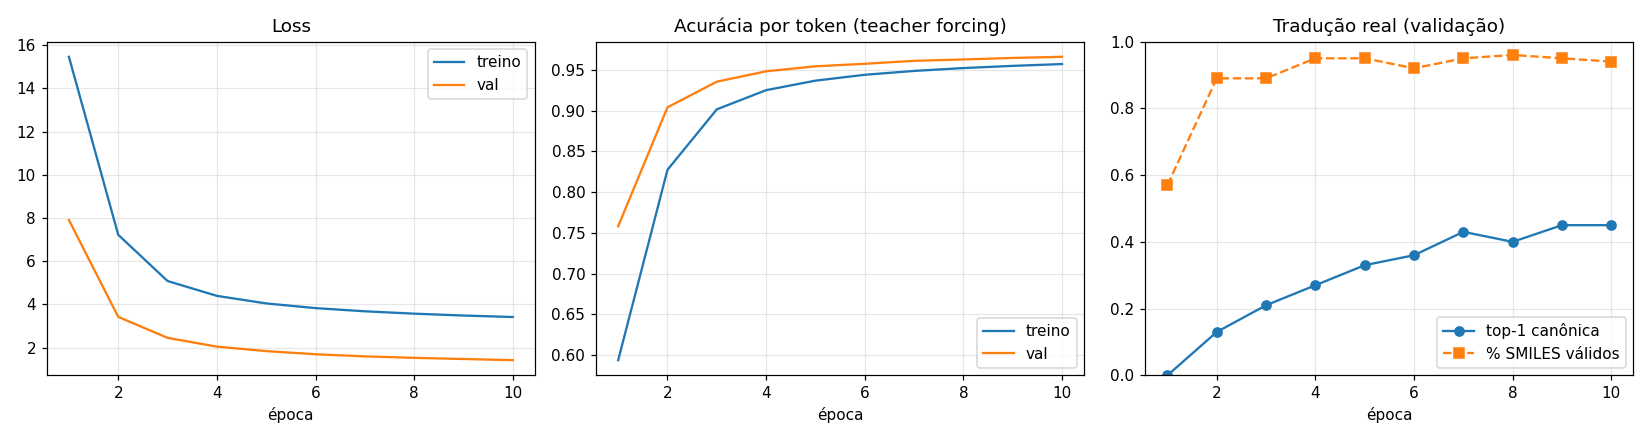

In [28]:
from IPython.display import Image, display
display(Image(os.path.join(CONFIG['work_dir'], 'historico_traducao.png')))

## Traduzir uma reação

In [29]:
gram = GramaticaSMILES(tok2id) if CONFIG["usar_sbs"] else None
reag = "COc1ccc(CO)cc1Oc1cccc(Cl)c1.c1ccc(P(c2ccccc2)c2ccccc2)cc1.O=C1CCC(=O)N1Br.ClCCl"
print(traduzir(model, reag, tok2id, id2tok, CONFIG["max_len"], beam_width=5, n_best=3, gram=gram))
# esperado: COc1ccc(CBr)cc1Oc1cccc(Cl)c1

['COc1ccc(CBr)cc1Oc1cccc(Cl)c1', 'COc1ccc(CCl)cc1Oc1cccc(Cl)c1', 'COc1ccc(CBr)cc1Oc1ccccc1']


In [30]:
# ============================================================
# TESTE DE TRADUÇÃO (reagentes -> produtos)
# ============================================================
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

logger.info("\n" + "=" * 60)
logger.info("TESTE DE TRADUÇÃO (reagentes -> produtos)")
logger.info("=" * 60)

def _canon(smi):
    """SMILES canônico ou None se inválido."""
    if not smi:
        return None
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else None

# ------------------------------------------------------------
# 1. Pegar amostras reais do dataset (com ground truth)
# ------------------------------------------------------------
df_teste = pd.read_csv(
    "/kaggle/input/datasets/glaucosoares/dados-reacoes/dados_reacoes.csv",
    nrows=50
)

# Detecta automaticamente a coluna de produtos (ajuste o nome se souber)
col_prod = next(
    (c for c in df_teste.columns
     if 'prod' in c.lower() or 'output' in c.lower()),
    None
)
if col_prod is None:
    raise ValueError(f"Coluna de produtos não encontrada. Colunas: {df_teste.columns.tolist()}")

amostras = df_teste[['input_reagentes', col_prod]].dropna().astype(str).sample(30, random_state=113)

pares = list(zip(amostras['input_reagentes'], amostras[col_prod]))

# ------------------------------------------------------------
# 2. Reações conhecidas adicionadas manualmente (reagente, produto esperado)
# ------------------------------------------------------------
pares.append((
    "COc1ccc(CO)cc1Oc1cccc(Cl)c1.c1ccc(P(c2ccccc2)c2ccccc2)cc1.O=C1CCC(=O)N1Br.ClCCl",
    "COc1ccc(CBr)cc1Oc1cccc(Cl)c1"
))  # bromação benzílica com NBS (exemplo do seu teste)
pares.append(("CC(=O)Cl.Oc1ccccc1", "CC(=O)Oc1ccccc1"))  # acetilação do fenol
pares.append(("CCO", "C=C"))  # desidratação do etanol (simples)

# ------------------------------------------------------------
# 3. Recarregar modelo salvo
# ------------------------------------------------------------
tok2id, id2tok = carregar_vocab(
    "/kaggle/working/vocab_tokens.json"
)
model, tok2id, id2tok, config = carregar_modelo(
    "/kaggle/working/trad_best.pt",
    "/kaggle/working/vocab_tokens.json"
)
model.eval()

gram = GramaticaSMILES(tok2id) if CONFIG["usar_sbs"] else None

# ------------------------------------------------------------
# 4. Loop de tradução com beam search + métricas
# ------------------------------------------------------------
n_amostras      = 0
acertos_top1    = 0   # 1º candidato == esperado (canônico)
acertos_topn    = 0   # esperado aparece entre os n_best candidatos
validas_top1    = 0   # 1º candidato é SMILES válido
candidatos_ok   = 0
candidatos_tot  = 0

N_BEST = 3

for i, (reag, esperado) in enumerate(pares):
    saida = traduzir(model, reag, tok2id, id2tok, CONFIG["max_len"],
                     beam_width=5, n_best=N_BEST, gram=gram)

    # Se traduzir retornar apenas uma string, normaliza para lista
    if isinstance(saida, str):
        candidatos = [saida]
    elif isinstance(saida, tuple):  # ex.: (lista, scores)
        candidatos = list(saida[0])
    else:
        candidatos = list(saida)
    candidatos = candidatos[:N_BEST]

    canon_esp = _canon(esperado)
    n_amostras += 1
    candidatos_tot += len(candidatos)

    # Top-1
    top1 = candidatos[0] if candidatos else ""
    canon_top1 = _canon(top1)
    if canon_top1 is not None:
        validas_top1 += 1
    if canon_esp is not None and canon_top1 == canon_esp:
        acertos_top1 += 1

    # Top-n
    if canon_esp is not None and any(_canon(c) == canon_esp for c in candidatos):
        acertos_topn += 1

    candidatos_ok += sum(1 for c in candidatos if _canon(c) is not None)

    # Relatório individual
    logger.info(f"\n[{i+1}] Reagentes: {reag[:100]}{'...' if len(reag) > 100 else ''}")
    logger.info(f"    Esperado: {esperado}{' (canon: ' + canon_esp + ')' if canon_esp else ' (INVÁLIDO no ground truth!)'}")
    logger.info(f"    Top-{len(candidatos)}:")
    for rank, c in enumerate(candidatos, 1):
        mol_ok = "válida" if _canon(c) else "INVÁLIDA"
        match  = "EXATO" if (canon_esp and _canon(c) == canon_esp) else "difere"
        logger.info(f"      {rank}. {c}  [{mol_ok} | {match}]")
    logger.info("-" * 60)

# ------------------------------------------------------------
# 5. Resumo das métricas
# ------------------------------------------------------------
logger.info("\n" + "=" * 60)
logger.info("RESUMO DA TRADUÇÃO")
logger.info("=" * 60)
logger.info(f"Amostras testadas:        {n_amostras}")
logger.info(f"Top-1 válido (RDKit):     {validas_top1}/{n_amostras} = {100*validas_top1/n_amostras:.1f}%")
logger.info(f"Top-1 exato (canônico):   {acertos_top1}/{n_amostras} = {100*acertos_top1/n_amostras:.1f}%")
logger.info(f"Top-{N_BEST} hit (canônico):    {acertos_topn}/{n_amostras} = {100*acertos_topn/n_amostras:.1f}%")
logger.info(f"Validade de todos os candidatos: {candidatos_ok}/{candidatos_tot} = "
            f"{100*candidatos_ok/max(candidatos_tot,1):.1f}%")

# Exemplo isolado (mesmo formato do seu snippet):
reag = "COc1ccc(CO)cc1Oc1cccc(Cl)c1.c1ccc(P(c2ccccc2)c2ccccc2)cc1.O=C1CCC(=O)N1Br.ClCCl"
print(traduzir(model, reag, tok2id, id2tok, CONFIG["max_len"],
               beam_width=5, n_best=3, gram=gram))
# esperado: COc1ccc(CBr)cc1Oc1cccc(Cl)c1

2026-09-29 22:55:29,189 - INFO - 
2026-09-29 22:55:29,190 - INFO - TESTE DE TRADUÇÃO (reagentes -> produtos)
2026-09-29 22:55:29,191 - INFO - ============================================================
/tmp/ipykernel_58/1838099186.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers, norm=nn.LayerNorm(embed_dim))
2026-09-29 22:55:29,300 - INFO - Modelo: 7,469,171 parâmetros
2026-09-29 22:55:29,604 - INFO - 
[1] Reagentes: O=C([O-])[O-].[K+].[K+].O=C(CCCN1CCN(c2ccccc2)CC1)c1ccc2c(c1)CCN(C(=O)C(F)(F)F)CC2.CO
2026-09-29 22:55:29,605 - INFO -     Esperado: O=C(CCCN1CCC(c2ccccc2)CC1)c1ccc2c(c1)CCNCC2 (canon: O=C(CCCN1CCC(c2ccccc2)CC1)c1ccc2c(c1)CCNCC2)
2026-09-29 22:55:29,605 - INFO -     Top-3:
2026-09-29 22:55:29,607 - INFO -       1. O=C(CCCN1CCN(c2ccccc2)CC1)c1ccc2c(c1)CCNCC2  [válida | difere]
2026-09-29 22:55:29,608 - INFO -       2. O=C(CCCN1CCNCC1)

['COc1ccc(CBr)cc1Oc1cccc(Cl)c1', 'COc1ccc(CCl)cc1Oc1cccc(Cl)c1', 'COc1ccc(CBr)cc1Oc1ccccc1']
